# Aufgabenstellung: Vorhersage von IT-Geräten aus Budget

**Ziel:**

Gegeben ein verfügbares Budget, soll ein Modell die anzahl der zu kaufenden IT-Geräte vorhersagen.

**Input:**

- Budget (z. B. in Euro)

**Outputs (Vorhersagen):**

- Anzahl der Computer

- Anzahl der Monitore 

- Anzahl der Drucker

- Anzahl der Mäuse

**Kurzbeschreibung:**

Das Modell soll lernen, wie viele Geräte eines Typs gekauft werden können, basierend auf dem verfügbaren Budget, um eine optimale Budgetallokation für IT-Hardware zu ermöglichen.

**Daten-Ausschnitt:**

Computer	Monitor	Drucker	Maus	Budget
===========================================
- 0   0	  1	  0	   101.98
- 1	  0	  0	  1	   641.66
- 0	  3	  0	  3	   450.45
- 0	  0	  1	  1	   123.01
- 1   0	  0	  2	   653.3
- 0	  4	  1	  0	   594.92
- 0	  0	  0	  0	   6.93

## 1 LinearRegression(): Ergebnis: schlecht weil die Daten nicht lineares Problem darstellen

In [29]:
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from sklearn.linear_model import LinearRegression, Ridge, Lasso


def my_custom_function(x):
# Beispiel: Werte > 0.5 zu 1 machen, sonst 0  
    return tf.round(x)


# CSV-Datei einlesen
df = pd.read_csv("IT-Equipment.csv", sep="\t")
print(df.head())

# Input & Output
X = df[["Budget"]]  # Input
y = df[["Computer", "Monitor", "Drucker", "Maus"]]  # Output
print("y.shap", y.shape, type(y))
print(y.head())

# Train-Test-Split
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

reg = LinearRegression()
reg.fit(x_train, y_train)


print("R² (Train):", reg.score(x_train, y_train))
print("R² (Val):", reg.score(x_val, y_val))



   Computer  Monitor  Drucker  Maus  Budget
0         0        0        1     0  101.98
1         1        0        0     1  641.66
2         0        3        0     3  450.45
3         0        0        1     1  123.01
4         1        0        0     2  653.30
y.shap (891, 4) <class 'pandas.core.frame.DataFrame'>
   Computer  Monitor  Drucker  Maus
0         0        0        1     0
1         1        0        0     1
2         0        3        0     3
3         0        0        1     1
4         1        0        0     2
R² (Train): 0.20708431461982288
R² (Val): 0.19668379200892122


## 2 model = keras.models.Sequential(): Ergebnis: mit 10000 Epoches und callbacks.ReduceLROnPlateau), beträchtliches Ergebnis

In [ ]:
reduce_lr= keras.callbacks.ReduceLROnPlateau(
    monitor='loss',   # Metrik, die beobachtet wird
    factor=0.1,           # Multiplikator: lr = lr * factor
    patience=500,          # wie viele Epochen ohne Verbesserung bevor lr gesenkt wird
    min_lr=1e-6,          # untere Grenze der lr
    cool_down=500,
    verbose=0             # Ausgabe im Training
)


   Computer  Monitor  Drucker  Maus  Budget
0         0        0        1     0  101.98
1         1        0        0     1  641.66
2         0        3        0     3  450.45
3         0        0        1     1  123.01
4         1        0        0     2  653.30


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_126 (Dense)               │ (None, 200)            │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_127 (Dense)               │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_129 (Dense)               │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_130 (Dense)               │ (None, 200)            │        40,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_131 (Dense)               │ (None, 4)              │           804 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,004 (632.83 KB)

 Trainable params: 162,004 (632.83 KB)

 Non-trainable params: 0 (0.00 B)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Training R²: 0.9456479549407959
Validation R²: 0.8749269247055054


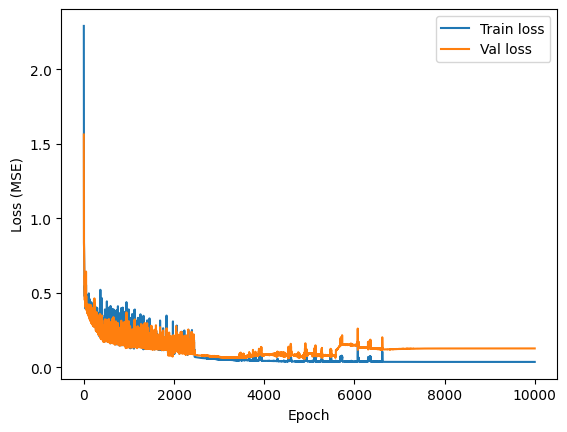

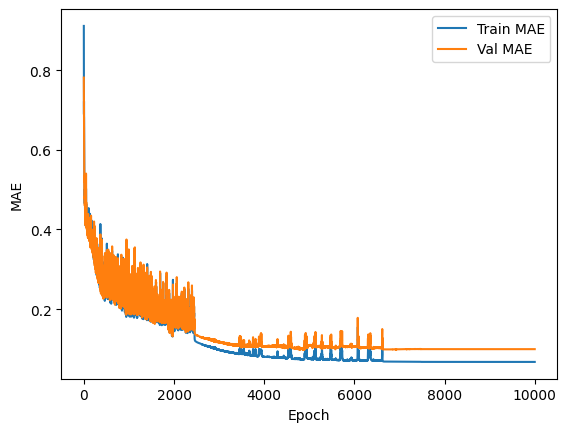

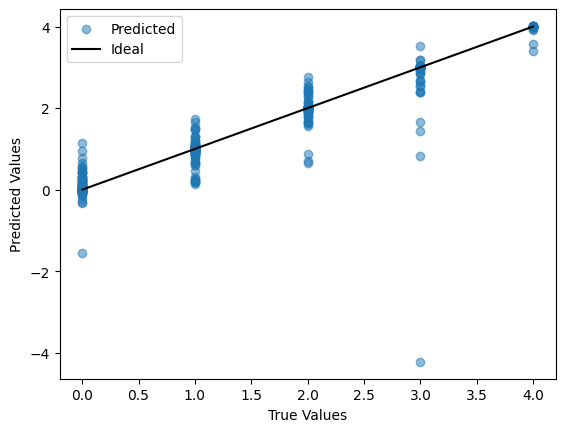

In [26]:
import numpy as np
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow import keras

import random
import os

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

# für deterministische GPU (langsam!)
os.environ["TF_DETERMINISTIC_OPS"] = "1"


# CSV-Datei einlesen
df = pd.read_csv("IT-Equipment.csv", sep="\t")
print(df.head())

# Input & Output
X = df[["Budget"]]  # Input
y = df[["Computer", "Monitor", "Drucker", "Maus"]]  # Output

# Train-Test-Split
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalierung Budget
scaler_x = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)

# Modell
model = keras.models.Sequential()
model.add(keras.layers.Input((1,)))

anzahl_lalyers=5
anz_neuron=200 #250
for _ in range(anzahl_lalyers):
    model.add(keras.layers.Dense(anz_neuron, activation='relu'))

# model.add(keras.layers.Dense(4))
model.add(keras.layers.Dense(4, activation='linear'))
        
#opt = keras.optimizers.Adam(learning_rate=0.01)
opt = keras.optimizers.Adam(learning_rate=0.01)
# mae
model.compile(loss='mse', optimizer=opt, metrics=['mae'])

reduce_lr= keras.callbacks.ReduceLROnPlateau(
    monitor='loss',   # Metrik, die beobachtet wird
    factor=0.1,           # Multiplikator: lr = lr * factor
    patience=500,          # wie viele Epochen ohne Verbesserung bevor lr gesenkt wird
    min_lr=1e-6,          # untere Grenze der lr
    cool_down=500,
    verbose=0             # Ausgabe im Training
)


model.summary()

# Training
history = model.fit( 
    x_train, y_train,
    batch_size=100,
    epochs=10000,
    validation_data=(x_val, y_val),
    callbacks=reduce_lr,
    verbose=0 # 1: ausdruck von iteration
)

# --- R² Score berechnen ---
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

print("Training R²:", r2_score(y_train, y_train_pred))
print("Validation R²:", r2_score(y_val, y_val_pred))


# --- Trainingsverlauf plotten ---
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.show()

plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.show()


# Modell speichern
model.save('model_budget.keras')

# Modell wieder laden
model_budget = keras.models.load_model('model_budget.keras')

# Scatterplot: True vs Predicted
plt.scatter(y_val, y_val_pred, alpha=0.5, label='Predicted')
plt.plot([y_val.min().min(), y_val.max().max()],
         [y_val.min().min(), y_val.max().max()],
         color='black', label='Ideal')
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.show()


## 3 Vergleich: model = keras.models.Sequential() mit ML-Algorithmen
- models = {
    - "LinearRegression": LinearRegression(),
    - "Ridge": Ridge(alpha=1.0),
    - "DecisionTree": DecisionTreeRegressor(random_state=42),
    - "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    - "KNN": KNeighborsRegressor(n_neighbors=5),
    - "SVR (RBF)": MultiOutputRegressor(SVR(kernel="rbf"))
### Ergebnis: DecisionTree(), RandomForest(), KNN(): sehr gutes Ergebnis, dageben:  LinearRegression(), Ridge() und SVR(): schlechtes Ergebnis

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 250)            │           500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 250)            │        62,750 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 4)              │         1,004 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 945,764 (3.61 MB)

 Trainable params: 315,254 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 630,510 (2.41 MB)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
🔹 Keras NN
Train R²: 0.7454109191894531
Val   R²: 0.7071724534034729

🔹 LinearRegression
Train R²: 0.20708431461982296
Val   R²: 0.1966837920089212

🔹 Ridge
Train R²: 0.20669035012647874
Val   R²: 0.19624197433423513

🔹 DecisionTree
Train R²: 1.0
Val   R²: 0.9773357691280908

🔹 RandomForest
Train R²: 0.9923584995859971
Val   R²: 0.9725595054829803

🔹 KNN
Train R²: 0.9546100120457419
Val   R²: 0.9236444180703306

🔹 SVR (RBF)
Train R²: 0.3834313688353031
Val   R²: 0.3620380665901999



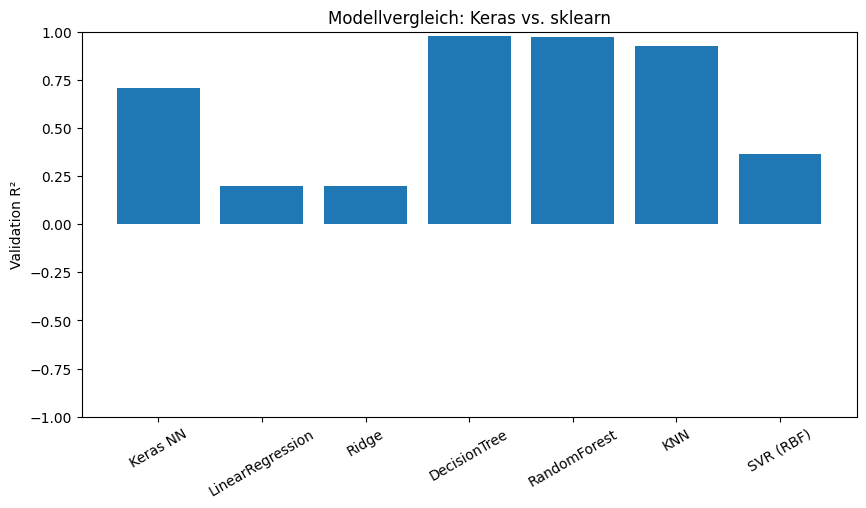

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor

import tensorflow as tf
from tensorflow import keras
import random
import os

seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)

# für deterministische GPU (langsam!)
os.environ["TF_DETERMINISTIC_OPS"] = "1"


# --- Daten laden ---
df = pd.read_csv("IT-Equipment.csv", sep="\t")

X = df[["Budget"]]  # Input
y = df[["Computer", "Monitor", "Drucker", "Maus"]]  # Output

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalierung Budget
scaler_x = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)

# --- Ergebnisse speichern ---
results = {}

# --- 1) Keras Modell ---
model = keras.models.Sequential()
model.add(keras.layers.Input((1,)))
anzahl_lalyers=6
for _ in range(anzahl_lalyers):
    model.add(keras.layers.Dense(250, activation='relu'))
    
model.add(keras.layers.Dense(4, activation='linear'))

opt = keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='mse', optimizer=opt, metrics=['mae'])

model.fit(x_train, y_train, batch_size=32, epochs=200, validation_data=(x_val, y_val), verbose=0)

model.summary()

y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

results["Keras NN"] = r2_score(y_val, y_val_pred)

print("🔹 Keras NN")
print("Train R²:", r2_score(y_train, y_train_pred))
print("Val   R²:", results["Keras NN"])
print("")

# --- 2) Sklearn Modelle ---
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "SVR (RBF)": MultiOutputRegressor(SVR(kernel="rbf"))
}

for name, m in models.items():
    m.fit(x_train, y_train)
    y_train_pred = m.predict(x_train)
    y_val_pred = m.predict(x_val)
    results[name] = r2_score(y_val, y_val_pred)
    print(f"🔹 {name}")
    print("Train R²:", r2_score(y_train, y_train_pred))
    print("Val   R²:", results[name])
    print("")

# --- Balkendiagramm Validation-R² ---
plt.figure(figsize=(10,5))
plt.bar(results.keys(), results.values())
plt.ylabel("Validation R²")
plt.title("Modellvergleich: Keras vs. sklearn")
plt.xticks(rotation=30)
plt.ylim(-1, 1)  # Skala für Übersicht
plt.show()


## 4 SVR mit GridSearchCV tunen: getrennte Betrachtung wie bei LinearRegression(), nur  gutes Ergebnis für Computer
SVR (RBF) ist empfindlich gegenüber Hyperparametern, besonders wenn:

Du nur ein Feature (Budget) hast, das die Ausgaben für mehrere Geräte erklärt.

Die Zielvariablen stark diskret oder sprunghaft sind (z. B. Drucker = 0 oder 1, Maus = 0–3).

Warum SVR hier schwach ist

SVR versucht, eine glatte Kurve zu fitten (RBF-Kernel),

aber deine Targets haben quasi stufenartige Sprünge, die besser durch Baumbasierte Modelle oder kNN gelernt werden.

Deshalb:

Computer → SVR kann einigermaßen approximieren → R² ≈ 0.94

Drucker / Maus → zu diskret → R² ≈ 0

In [7]:

import numpy as np

import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVR

# --- CSV laden ---
df = pd.read_csv("IT-Equipment.csv", sep="\t")

X = df[["Budget"]]  # Input
y = df[["Computer", "Monitor", "Drucker", "Maus"]]  # Output

# --- Train/Test Split ---
x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Skalierung Budget ---
scaler_x = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)

# --- Parameter-Raum ---
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
    "epsilon": [0.01, 0.1, 0.2, 0.5]
}

# --- SVR für jede Zielspalte ---
svr_results = {}

for i, col in enumerate(y_train.columns):
    
    y_train_single = y_train.iloc[:, i]
    y_val_single = y_val.iloc[:, i]
    #print(y_train_single)
    #print(y_val_single)

    svr = SVR(kernel="rbf")
    grid = GridSearchCV(svr, param_grid, cv=5, scoring="r2", n_jobs=-1)
    grid.fit(x_train, y_train_single)

    best_svr = grid.best_estimator_

    svr_results[col] = {
        "best_params": grid.best_params_,
        "train_r2": best_svr.score(x_train, y_train_single),
        "val_r2": best_svr.score(x_val, y_val_single)
    }

# --- Ergebnisse anzeigen ---
df_res=  pd.DataFrame(svr_results)
#print("df_res", df_res)
print("============")
results_df = pd.DataFrame(svr_results).T
print(results_df)


                                            best_params  train_r2    val_r2
Computer   {'C': 100, 'epsilon': 0.1, 'gamma': 'scale'}  0.928961  0.942841
Monitor    {'C': 100, 'epsilon': 0.5, 'gamma': 'scale'}  0.793094  0.795139
Drucker     {'C': 10, 'epsilon': 0.2, 'gamma': 'scale'} -0.008883 -0.030257
Maus      {'C': 0.1, 'epsilon': 0.01, 'gamma': 'scale'} -0.002998 -0.017074


## 5 Keras NN tunen mit callback EarlyStopping()

## 5.1 Variant: : n_neurons=250, batch_size=32 (keine Verbesserung erzielt)
n_hidden=5
n_neurons=200
batch_size=32

Train R²: 0.8350571393966675

Val   R²: 0.7877396941184998

In [40]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

# --- Daten laden ---
df = pd.read_csv("IT-Equipment.csv", sep="\t")
X = df[["Budget"]]
y = df[["Computer", "Monitor", "Drucker", "Maus"]]

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Skalierung
scaler_x = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)

# --- Keras Modell ---
def build_model(input_dim, output_dim, n_hidden=3, n_neurons=128, activation="relu", lr=0.001):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    for _ in range(n_hidden):
        model.add(layers.Dense(n_neurons, activation=activation))
        
    model.add(layers.Dense(output_dim, activation="linear"))

    optimizer = keras.optimizers.Adam(learning_rate=lr)
    model.compile(loss="mse", optimizer=optimizer, metrics=["mae"])
    return model

n_hidden=5
n_neurons=150
batch_size=64 #64
model = build_model(input_dim=x_train.shape[1], output_dim=y_train.shape[1],
                    n_hidden=n_hidden, n_neurons=n_neurons, lr=0.001)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)

#  n_hidden=4, n_neurons=250,  batch_size=32
#  n_hidden=5, n_neurons=200,   batch_size=32

history = model.fit(x_train, y_train, 
                    validation_data=(x_val, y_val),
                    epochs=5000, batch_size=batch_size,
                    callbacks=[early_stop],
                    verbose=0)

# --- R² ---
y_train_pred = model.predict(x_train)
y_val_pred = model.predict(x_val)

print("Train R²:", r2_score(y_train, y_train_pred))
print("Val   R²:", r2_score(y_val, y_val_pred))


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Train R²: 0.8254349231719971
Val   R²: 0.795469343662262


## 6 Da die Zielvariablen (Computer, Monitor, Drucker, Maus)  diskrete Werte haben, können  sie besser als klassifikatorisches Problem behandelt werden:

- Jede Zielspalte → eigene Softmax-Klassifikation

- Modell gibt für jede Kategorie Wahrscheinlichkeiten aus

- Sequential → nur eine lineare Kette von Schichten möglich, ein Input, ein Output.

- Mehrere Outputs oder Verzweigungen funktioniert hier nicht.

Deshalb hier die funktionale API, um mehrere Outputs (Computer, Monitor, …) zu definieren:
### Am Ende wählen wir argmax, um die Vorhersage zu bekommen

============================

Jede Zielspalte wird getrennt vorhergesagt, aber sie teilt sich die gleiche Feature-Repräsentation aus den Hidden Layers.

Das ist also ein Multi-Task-Learning-Setup:

Es gibt eine Interaktion durch die gemeinsamen Hidden Layers.

Aber die Entscheidung pro Spalte ist unabhängig, weil jede Zielvariable ihre eigene Output-Schicht hat.
Jede Zielspalte wird getrennt vorhergesagt, aber sie teilt sich die gleiche Feature-Repräsentation aus den Hidden Layers.

Das ist also ein Multi-Task-Learning-Setup:

Es gibt eine Interaktion durch die gemeinsamen Hidden Layers.

Aber die Entscheidung pro Spalte ist unabhängig, weil jede Zielvariable ihre eigene Output-Schicht hat.
### die gemeinsame Repräsentation
hidden1 = layers.Dense(64, activation="relu")(inputs)

hidden2 = layers.Dense(64, activation="relu")(hidden1)

    inputs: Form (None, 1) weil Budget nur 1 Feature hat.

    hidden1 → Outputform (None, 64); hidden2 → (None, 64).

    Wichtig: Diese beiden Layers sind gemeinsam für alle Outputs — hier entsteht die gemeinsame Repräsentation.

### losses = {
   - "Computer": "categorical_crossentropy",
   - "Monitor": "categorical_crossentropy",
   - "Drucker": "categorical_crossentropy",
  -  "Maus": "categorical_crossentropy"
}
###  Loss Weights verwenden
loss_weights = {
- "Computer": 1.0,   # doppelt so wichtig
  -  "Monitor": 1.0,
  -  "Drucker": 1.0,
  -  "Maus": 0.5
}

model.compile(
    - optimizer=keras.optimizers.Adam(0.001),
    - loss=losses,
    - loss_weights=loss_weights,   # <<<< hier
    -  metrics=metrics )
    
"Maus": 0.5
- Computer Accuracy: 1.0
- Monitor Accuracy: 0.9217877094972067
- Drucker Accuracy: 0.7094972067039106
- Maus Accuracy: 0.30726256983240224
- 
"Maus": 1.0
- Computer Accuracy: 1.0
- Monitor Accuracy: 0.9162011173184358
- Drucker Accuracy: 0.7318435754189944
- Maus Accuracy: 0.33519553072625696

### Confusion Matrix: Spalte 4: alle sind 0. keine Veraossage für Maus
[[43 17  3  0]

 [38 12  5  0]
 
 [22  8  6  0]
 
 [21  2  2  0]]

## 6.1 sample_weights[col]

 **weights = compute_class_weight(class_weight="balanced", classes=classes, y=y[col])**

compute_class_weight kommt aus sklearn.utils.class_weight.

class_weight="balanced" heißt: die Gewichtung wird so berechnet, dass seltene Klassen stärker gewichtet werden und häufige Klassen weniger.

classes=np.unique(y_train[col]): Liste aller vorkommenden Klassen in dieser Spalte.

y=y_train[col]: die tatsächlichen Labels für diese Spalte im Trainingsset.

📌 Beispiel: Wenn "Drucker" 530 mal 0 und nur 180 mal 1 ist → dann bekommt Klasse 1 ein größeres Gewicht.

Das Ergebnis ist ein Array mit Gewichten, z. B. [0.67, 1.96].

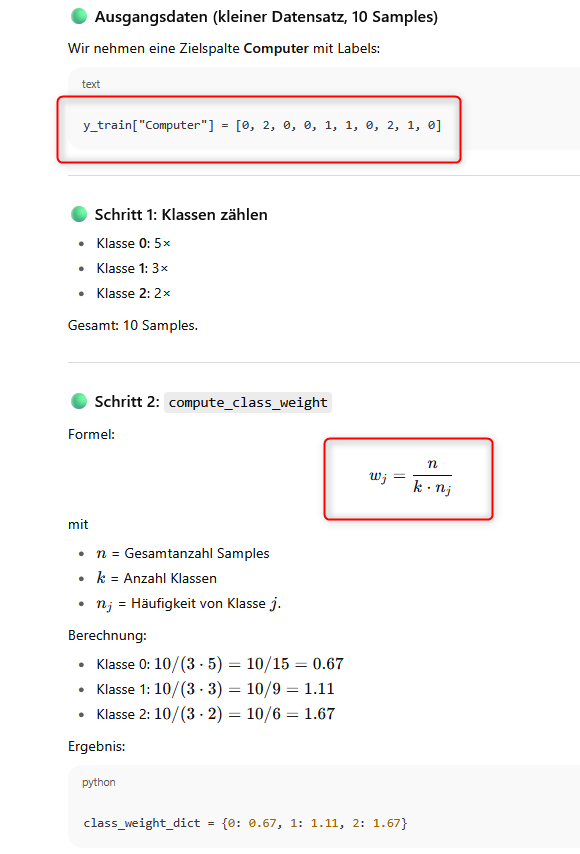

### Rechenbeispiel: sample_weights[col] 
col, classes:  Computer [0 1 2]

- class_weight_dict: **[ 0.43388178  1.56140351 18.25641026]** <class 'numpy.ndarray'>
- class_weight_dict-1: {np.int64(0): np.float64(0.43388177940280315), np.int64(1): np.float64(1.5614035087719298), np.int64(2): np.float64(18.256410256410255)}
- sample_weights[col]: [ 0.43388178 18.25641026  0.43388178  0.43388178  0.43388178  1.56140351
  1.56140351  1.56140351  0.43388178  0.43388178]
  
col, classes:  Monitor [0 1 2 3 4]

- class_weight_dict: **[0.6562212  0.84761905 1.04705882 1.1483871  2.12537313]** <class 'numpy.ndarray'>
- class_weight_dict-1: {np.int64(0): np.float64(0.656221198156682), np.int64(1): np.float64(0.8476190476190476), np.int64(2): np.float64(1.0470588235294118), - np.int64(3): np.float64(1.1483870967741936), np.int64(4): np.float64(2.1253731343283584)}
- sample_weights[col]: [0.84761905 0.6562212  0.6562212  1.1483871  2.12537313 0.84761905
 2.12537313 0.84761905 0.6562212  2.12537313]
  
col, classes:  Drucker [0 1]

- class_weight_dict: **[0.67043315 1.96685083]** <class 'numpy.ndarray'>
- class_weight_dict-1: {np.int64(0): np.float64(0.6704331450094162), np.int64(1): np.float64(1.9668508287292819)}
- sample_weights[col]: [0.67043315 1.96685083 0.67043315 0.67043315 0.67043315 0.67043315
 0.67043315 1.96685083 1.96685083 0.67043315]
  
col, classes:  Maus [0 1 2 3]

- class_weight_dict: **[0.63799283 0.90816327 1.22758621 1.93478261]** <class 'numpy.ndarray'>
- class_weight_dict-1: {np.int64(0): np.float64(0.6379928315412187), np.int64(1): np.float64(0.9081632653061225), np.int64(2): np.float64(1.2275862068965517), np.int64(3): np.float64(1.934782608695652)}

- sample_weights[col]: [1.93478261 0.63799283 1.93478261 0.90816327 0.63799283 1.22758621
 1.22758621 0.63799283 0.90816327 0.90816327]


## 6.2. Zielspalten: Computer, Monitor, Drucker, Maus als getrennte Klasse trainieren, aber mit gemeinsamen Hiddenlayers

### "balanced" the weight with sample_weights = {}

for col in y.columns:

    # Nur Trainingsteil nehmen!
    
    class_weight_dict = compute_class_weight(
       class_weight="balanced",
        classes=np.unique(y_train[col]),
        y=y_train[col]
    )
    
    class_weight_dict = dict(zip(np.unique(y_train[col]), class_weight_dict))
    
    # Mappe Gewicht pro Sample (nur für Trainingssplit)
    
    sample_weights[col] = y_train[col].map(class_weight_dict).values

### Ergebnis:  ziemlich gutes Ergebnis

- Computer Accuracy: 1.0: sicheres Ergebnis
- Monitor Accuracy: 0.9776536312849162 : sicheres Ergebnis
- Drucker Accuracy: 0.8715083798882681 : gutes Ergebnis
- Maus Accuracy: 0.5977653631284916: nicht so gutes Ergebnis, der Grund ist die Datenlage von Maus

In [31]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, r2_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import random
import os


seed = 42
np.random.seed(seed)
random.seed(seed)
tf.random.set_seed(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
# für deterministische GPU (langsam!)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

# --- Daten laden ---
df = pd.read_csv("IT-Equipment.csv", sep="\t")
print(df.shape)
X = df[["Budget"]]
y = df[["Computer", "Monitor", "Drucker", "Maus"]]

x_train, x_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print("x_train:",  type(x_train))
# Skalierung
scaler_x = MinMaxScaler()
x_train = scaler_x.fit_transform(x_train)
x_val = scaler_x.transform(x_val)

#for col in  ["Drucker", "Maus"]:  # nur die Problem-Spalten
for col in y.columns:  # nur die Problem-Spalten
    print(f"\n=== Klassenverteilung für {col} ===")
    print("Training:")
    print(y_train[col].value_counts())   # Verteilung im Training
    print("Validation:")
    print(y_val[col].value_counts())  # Verteilung im Validation-Set

print()

# --- Zielwerte in Klassen kodieren durchOneHot für jede Klasse---
# die Klassen sind Zahlen und man kann direkt mit OneHot encoding arbeiten
#  y_train_cat[col] = keras.utils.to_categorical(y_train[col], num_classes=n_cls)
num_classes = {}
y_train_cat = {}
y_val_cat = {}

for col in y.columns:
    n_cls = y[col].max() + 1
    num_classes[col] = n_cls # output perceptron
    print("n_cls", num_classes[col])
    y_train_cat[col] = keras.utils.to_categorical(y_train[col], num_classes=n_cls)
    print("col,    y_train_cat :", col,  y_train_cat[col])
    y_val_cat[col] = keras.utils.to_categorical(y_val[col], num_classes=n_cls)

#  Modell 
n_neurons=85
batch_size=100

# 2 Hideenlayers
inputs = keras.Input(shape=(x_train.shape[1],))
hidden1 = layers.Dense(n_neurons, activation="relu")(inputs)
hidden2 = layers.Dense(n_neurons, activation="relu")(hidden1)
#hidden3 = layers.Dense(n_neurons, activation="relu")(hidden2)

# Separate Outputs für jede Zielvariable: Computer, Monitore, Drucker, Maus
outputs = []
for col in y.columns:
    out = layers.Dense(num_classes[col], activation="softmax", name=col)(hidden2)
    outputs.append(out)

# ein input, 4-outputs in a list
model = keras.Model(inputs=inputs, outputs=outputs)

# dict:
losses = {col: "categorical_crossentropy" for col in y.columns}
metrics = {col: "accuracy" for col in y.columns}

# class_weights nicht benutzt im code, nur zum Testen
for col in ["Drucker", "Maus"]:
    classes = np.unique(y[col])
    weights = compute_class_weight(class_weight="balanced", classes=classes, y=y[col])
    class_weights = dict(zip(classes, weights))
    print(f"\nClass weights für {col}:", class_weights)

# manuell Gewichte zuweisen   
loss_weights = {
    "Computer": 1.0,   # doppelt so wichtig
    "Monitor": 1.0,
    "Drucker": 1.2,
    "Maus": 1.5
}

model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=losses,
    loss_weights=loss_weights,   # <<<< hier
    metrics=metrics
)

# für ein output
# model.compile(optimizer=keras.optimizers.Adam(0.001),loss="categorical_crossentropy",metrics=["accuracy"])

# --- Training ---
# [y_train_cat[c] for c in y.columns]
# [y_val_cat[c] for c in y.columns]
# Targets werden als Liste in exakt derselben Reihenfolge wie y.columns übergeben — 
# das ist wichtig, damit Targets und Outputs zusammenpassen.
#mytest_cols= [y_train_cat[c] for c in y.columns]
#print("=====mytest_cols \n", mytest_cols)
# Für jedes Output-Label sample weights bauen


sample_weights = {}
for col in y.columns:
    # Nur Trainingsteil nehmen!
    class_weight_dict = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(y_train[col]),
        y=y_train[col]
    )
    class_weight_dict = dict(zip(np.unique(y_train[col]), class_weight_dict))    
    # Mappe Gewicht pro Sample (nur für Trainingssplit)
    # Mappe Gewicht pro Sample (nur für Trainingssplit)
    # y_train["Computer"] = [0, 2, 0, 0, 0, 1, 1, 1, 0, ...]
    # class_weight_dict = {0: 0.4339, 1: 1.5614, 2: 18.2564}
    # map: 0: durch 0.4339, 1: durch 1.5614, 2: durch 18.2564 ersetzt--> sample_weights[col]    
    sample_weights[col] = y_train[col].map(class_weight_dict).values


history = model.fit(
    x_train,
    [y_train_cat[c] for c in y.columns],
    validation_data=(x_val, [y_val_cat[c] for c in y.columns]),
    epochs=10000,
    batch_size=batch_size,
    verbose=0,
    sample_weight=[sample_weights[c] for c in y.columns],  # <- Liste pro Output
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True)]
)


model.summary()

# --- Vorhersage ---
# model.predict(x_val) gibt eine Liste zurück, ein Element pro Output: 
# y_pred[i] hat Shape (n_samples, n_classes_for_output_i).
# np.argmax(..., axis=1) wandelt One-Hot-Probs in diskrete Klassen (0..n_cls-1).

y_pred = model.predict(x_val)
print("==========================")
print("computer: y_val\n", y_val.head())
print("computer: y_pred\n", y_pred[0][:10])
print("==========================")
y_pred_labels = {}
for i, col in enumerate(y.columns):
    y_pred_labels[col] = np.argmax(y_pred[i], axis=1)

#print("y_pred\n", y_pred)
print("y_pred_labels\n", y_pred_labels)

for i, col in enumerate(y.columns):
    print(f"\n=== Evaluation für {col} ===")   
    # Confusion Matrix
    cm = confusion_matrix(y_val[col], y_pred_labels[col])
    print("Confusion Matrix:")
    print(cm)
    
    # Classification Report (Precision, Recall, F1-Score)
    report = classification_report(y_val[col], y_pred_labels[col])
    print("Classification Report:")
    print(report)




# --- Accuracy prüfen ---
for col in y.columns:
    acc = accuracy_score(y_val[col], y_pred_labels[col])
    print(f"{col} Accuracy:", acc)

(891, 5)
x_train: <class 'pandas.core.frame.DataFrame'>

=== Klassenverteilung für Computer ===
Training:
Computer
0    547
1    152
2     13
Name: count, dtype: int64
Validation:
Computer
0    138
1     36
2      5
Name: count, dtype: int64

=== Klassenverteilung für Monitor ===
Training:
Monitor
0    217
1    168
2    136
3    124
4     67
Name: count, dtype: int64
Validation:
Monitor
0    55
1    45
2    34
3    26
4    19
Name: count, dtype: int64

=== Klassenverteilung für Drucker ===
Training:
Drucker
0    531
1    181
Name: count, dtype: int64
Validation:
Drucker
0    131
1     48
Name: count, dtype: int64

=== Klassenverteilung für Maus ===
Training:
Maus
0    279
1    196
2    145
3     92
Name: count, dtype: int64
Validation:
Maus
0    63
1    55
2    36
3    25
Name: count, dtype: int64

n_cls 3
col,    y_train_cat : Computer [[1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]
n_cls 5
col,    y_train_cat : Monitor [[0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]

Model: "functional_268"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_141 (Dense)   │ (None, 85)        │        170 │ input_layer_26[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_142 (Dense)   │ (None, 85)        │      7,310 │ dense_141[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Computer (Dense)    │ (None, 3)         │        258 │ dense_142[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Monitor (Dense)     │ (None, 5)         │        430 │ dense_142[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Drucker (Dense)     │ (None, 2)         │        172 │ dense_142[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Maus (Dense)        │ (None, 4)         │        344 │ dense_142[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 26,054 (101.78 KB)

 Trainable params: 8,684 (33.92 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 17,370 (67.86 KB)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
computer: y_val
      Computer  Monitor  Drucker  Maus
709         0        1        0     2
439         1        0        1     0
840         1        0        0     2
720         0        1        1     0
39          0        4        0     0
computer: y_pred
 [[1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [0.0000000e+00 1.0000000e+00 0.0000000e+00]
 [8.3470951e-31 1.0000000e+00 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00]
 [6.3503823e-22 1.0000000e+00 0.0000000e+00]
 [0.0000000e+00 1.9952420e-15 1.0000000e+00]
 [1.0000000e+00 0.0000000e+00 0.0000000e+00]]
y_pred_labels
 {'Computer': array([0, 1, 1, 0, 0, 0, 0, 1, 2, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
 